# Diffusion: from random motion to AI image generation

Many processes in nature involve random motion
 - Heat transport in solids
 - Virus particles spreading in air
 - Animals moving in ecosystems

These are commonly modelled by mathematicians as a random walk.

A single random walk seems completely unpredictable.

However, when you look at many random walkers, or at longer time and length scales, the average behaviour becomes predictable. There is a lot of mathematical theory - which you will learn as part of the MARS course - which can be used to describe this behaviour.

AI image generation models ("diffusion models") add random noise to images. They then learn how to reverse this random process, generating images from noise.


We start by importing some standard Python libraries - press shift+enter on each cell to run it:

In [12]:
# --- Imports ---
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

This is plotting code used later - please don't change this. Again, press shift+enter on the cell to run it: 

In [13]:
def visualize_positions(pos, trail=True, max_particles=1000):
    # --- Animation setup ---
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.set_aspect("equal")
    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 4)
    ax.set_title("Random walk (diffusion)")

    if trail:
        line, = ax.plot([], [], lw=2)
        point, = ax.plot([], [], "ro")
        
        def init():
            line.set_data([], [])
            point.set_data([], [])
            return line, point
        
        def update(frame):
            line.set_data(pos[:frame, 0], pos[:frame, 1])
            point.set_data([pos[frame, 0]], [pos[frame, 1]])
            return line, point
    else:
        scat = ax.scatter([], [], s=5, alpha=0.5)

        N = min(pos.shape[1], max_particles)
        
        def init():
            scat.set_offsets(np.empty((0, 2)))
            return scat,
        
        def update(frame):
            xy = pos[frame, :N]
            scat.set_offsets(xy)
            return scat,    
            
    anim = animation.FuncAnimation(
                fig,
                update,
                frames=len(pos),
                init_func=init,
                interval=50,
                blit=True
            )
    
    plt.close(fig)
    
    # --- Display animation ---
    return HTML(anim.to_jshtml())

## Part 1 - A single random particle

What are we modelling?
A particle that:
- takes small, random steps, and
- has no memory, i.e. the direction and length of the next step is not affected by earlier steps.

This is called a **random walk**. We can implement it as follows:

In [14]:
# --- Simulation ---
def simulate_one_particle(n_steps=300, step_size=0.1, seed=0):
    rng = np.random.default_rng(seed)
    pos = np.zeros((n_steps + 1, 2))
    for t in range(n_steps):
        step = step_size * rng.standard_normal(2)
        # OTHER OPTIONS TO CHOOSE (UNCOMMENT)
        #step = step_size * rng.choice([-1, 1], size=2)
        #step = step_size * np.array([rng.standard_normal(), 0])
        pos[t + 1] = pos[t] + step
    return pos

Here we have defined a function `simulate_one_particle` that first

- initalizes the random number generator
   ```rng = np.random.default_rng(seed)```

- makes an empty array of shape (n_steps + 1) x 2 to store the path of the particle
   ```pos = np.zeros((n_steps + 1, 2))```

and then loops over all of the timesteps. For each timestep, it

- generates a pair of normally distributed random numbers
    ```rng.standard_normal(2)```
- scales this by a number (the step-size)
    ```step = step_size * rng.standard_normal(2)```
- adds this to the current position `pos[t]` and stores it in `pos[t+1]`
    ```pos[t + 1] = pos[t] + step```
  Note that here `pos[t]` is the whole `t`-th row of the `pos` matrix.

Finally, it returns the position array (so that you can plot / visualize it).

The loop is illustrated in the video below


In [15]:
from IPython.display import Video
Video("ParticleUpdateStepGhost.mp4")

Now run the simulation:

In [16]:
pos = simulate_one_particle(n_steps=50, step_size=0.2, seed=0)

After the function has returned, `pos` is a `(n_steps+1) x 2` array, containing the positions of the particle at each timestep. It can be visualised interactively:

In [17]:
visualize_positions(pos)

### Tasks:
- change value of `step_size` in `pos = random_walk(n_steps=50, step_size=0.2, seed=0)` above and rerun the code for interactive visualisation. What is different?
- try other random motions in the definition of `random_walk` (see commented out code)

## Part 2 - Many particles

What changes when we simulate many particles? Each individual particle is random - but the average behaviour of the whole population of particles is predictable.

We can simulate many random walks at the same time with the following code:

In [39]:
def simulate_many_particles(n_particles=500, n_steps=300, step_size=0.1, seed=0):
    rng = np.random.default_rng(seed)
    pos = np.zeros((n_steps + 1, n_particles, 2))

    for t in range(n_steps):
        steps = step_size * rng.standard_normal((n_particles, 2))
        pos[t + 1] = pos[t] + steps

    return pos

This works in a very similar way to `simulate_one_particle`, except that we make a three-dimensional results array. Now, at each timestep, we generate the random moves for all particles at the same time `rng.standard_normal((n_particles, 2))`. Doing it like this in Python allows the `numpy` library to generate these numbers, and perform the scaling and addition, in parallel.

Now run the simulations with:

In [40]:
pos = simulate_many_particles(n_particles=5000, n_steps=50, step_size=0.2, seed=0)

It can be visualised as follows:

In [41]:
visualize_positions(pos, trail=False)

With many particles, many properties of the overall population can be predicted. For instance, as time $t$ grows, mathematical results establish that the average distance from the starting point is proportional to the square-root of time, $\sqrt{t}$. Lets verify this:

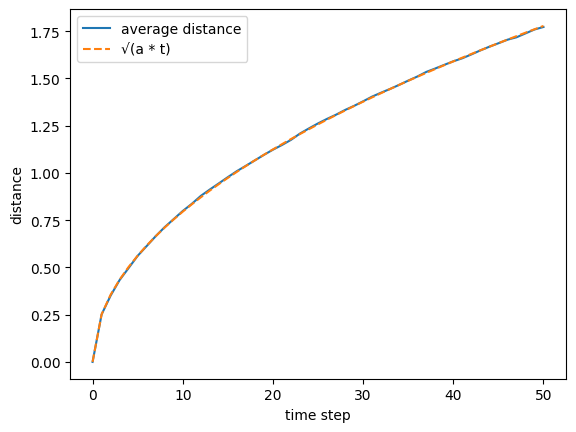

In [46]:
r = np.linalg.norm(pos, axis=2)
mean_r = r.mean(axis=1)

t = np.arange(len(mean_r))

# Find best fit (least squares error) for t ~ a mean_r**2
a = (t[1:] @ mean_r[1:]**2) / (t[1:] @ t[1:])


plt.figure()
plt.plot(t, mean_r, label="average distance")
plt.plot(t, np.sqrt(t)*np.sqrt(a), "--", label="√(a * t)")
plt.xlabel("time step")
plt.ylabel("distance")
plt.legend()
plt.show()

## Part 3 — From particles to pixels

- An image is just an array of numbers (pixels).
- We can treat each pixel like a 1D particle.
- Adding noise to an image = many particles undergoing random walks.

Let us first repear the above many participle simulation but in 1D:

In [27]:
def diffuse_1d(n_particles=10000, n_steps=200, step_size=0.1, seed=0):
    rng = np.random.default_rng(seed)
    x = np.zeros((n_steps + 1, n_particles))
    for t in range(n_steps):
        x[t+1] = x[t] + step_size * rng.standard_normal(n_particles)
    return x

In [28]:
x = diffuse_1d(n_particles=3000, n_steps=200, step_size=0.1, seed=0)

In [29]:
def visualize_1d(x):
    fig, ax = plt.subplots(figsize=(6, 3))
    
    ax.set_xlim(-4, 4)
    ax.set_ylim(-0.1, 0.1)
    ax.set_yticks([])
    ax.set_xlabel("position")
    ax.set_title("1D diffusion (same random walk, but 1D)")
    
    scat = ax.scatter([], [], s=5, alpha=0.5)
    
    def init():
        scat.set_offsets(np.empty((0, 2)))
        return scat,
    
    def update(frame):
        y = np.zeros_like(x[frame])  # all points on a line
        offsets = np.column_stack((x[frame], y))
        scat.set_offsets(offsets)
        return scat,
    
    anim = animation.FuncAnimation(
        fig,
        update,
        frames=x.shape[0],
        init_func=init,
        interval=40,
        blit=True
    )
    
    plt.close(fig)
    return HTML(anim.to_jshtml())

In [30]:
visualize_1d(x)

This is visually less pleasing, but one key insight is to plot **histograms**, which answer the following question:

**“At this time step, where are most of the particles?”**

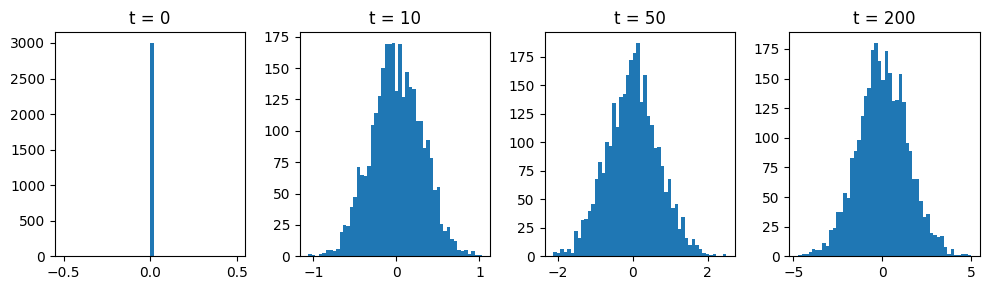

In [41]:
times = [0, 10, 50, 200]

plt.figure(figsize=(10,3))
for i, t in enumerate(times):
    plt.subplot(1, len(times), i+1)
    plt.hist(x[t], bins=50, density=False)
    plt.title(f"t = {t}")
plt.tight_layout()
plt.show()

Let us now load a grayscale example image from the leading open source machine learning library for image manipulation:

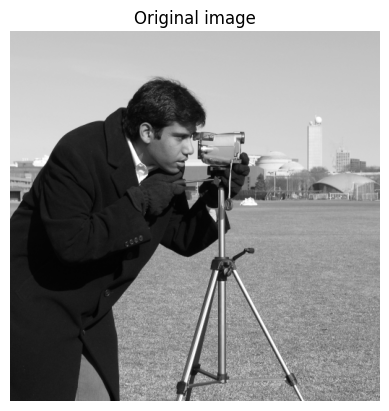

In [14]:
from skimage import data, img_as_float

img = img_as_float(data.camera())
plt.imshow(img, cmap="gray")
plt.title("Original image")
plt.axis("off")
plt.show()

We can diffuse the pixels:

In [15]:
def diffuse_image(image, sigma, seed=0):
    rng = np.random.default_rng(seed)
    return image + sigma * rng.standard_normal(image.shape)

and obtain noisy images:

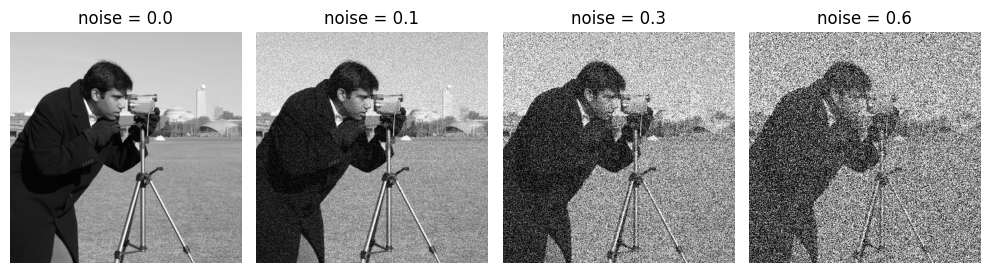

In [16]:
sigmas = [0.0, 0.1, 0.3, 0.6]

plt.figure(figsize=(10,3))
for i, s in enumerate(sigmas):
    noisy = diffuse_image(img, s)
    #noisy = np.clip(noisy, 0, 1)
    plt.subplot(1, len(sigmas), i+1)
    plt.imshow(np.clip(noisy, 0, 1), cmap="gray")
    plt.title(f"noise = {s}")
    plt.axis("off")
plt.tight_layout()
plt.show()

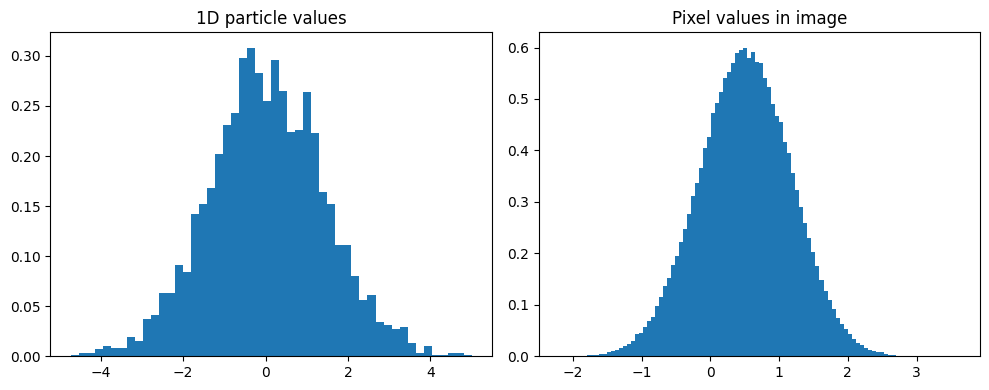

In [17]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(x[200], bins=50, density=True)
plt.title("1D particle values")

plt.subplot(1,2,2)
plt.hist(noisy.flatten(), bins=100, density=True)
plt.title("Pixel values in image")

plt.tight_layout()
plt.show()


## Part 4 - AI

[simple live demo of turning noise into an image goes here]